# Assignment 1 (CSI 4142)

# Exploratory Data Analysis (EDA)


## **Group Information**

- **Student name**: Shabrina Sharmin
- **Student Id**: 300230297
- **Group no**: A-85

## **Goal of the analysis**
The goal of this report is to download datasets, to analyze the datasets, and to summarize the datasets using Exploratory data analysis (EDA). This report will include a conclusive information such as the fearures of the datasets, underlining patterns of the datasets, existing relationships among various data features etc. This report will also include 10 insights for each of the datasets. Each insight will be validated with sufficient analytical explanation along with visual components. This report will use either Univariate or Bivariate analytical methodfor the visualization and analytic purpose. The reader of this report will be able to understand the nature of the data, get a summurized view of the dataset,and identify the underlining pattern of the dataset. Overall, this report will provide the reader an initial knowledge about the datasets which is a crucial step for data science.

## **Access data**

### **Local instruction for accessing dataset on kaggle:** ###
**Pre-Requisite:** User must respectively create and download their access token from https://www.kaggle.com/. If the user already has an existing kaggle token, then no need to create a new one. Just use the existing kaggle token (kaggle.json) as requested.
If the "kaggle.json" token is not under ".kaggle" folder in the home path, then place the kaggle.json in the same directoy as the notebook. The code below will copy the "kaggle.json" token to the correct location


In [ ]:

# Create a kaggle configuration folder/directory
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json  # Adjust the permissions of the file.





cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


### **Instruction for running in Google Colab** ###

Upon running the code in following section below, a prompt will pop up asking for the **'kaggle.json'** file. The user needs to click on the 'Choose file' option and navigate to the corresponding directory where the kaggle.json file should reside and choose **'kaggle.json'** file. At this point, the "kaggle.json" should be loaded to the instance of the colab.

In [ ]:
from os import mkdir

## Upload kaggle API credentials to Colab
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"shabrinasharmin","key":"62fe625309926cb95271b826f7908041"}'}

### **Setting up the appropriate libraries needed for the assignment** ##
Run the follwing code below to set up the appropriate libraries that are needed

In [ ]:
## Install Kaggle library
!pip install -q kaggle

!pip install pandas
!pip install seaborn
!pip install matplotlib
!pip install numpy



In [ ]:
## Download the dataset 1  [User mobile usage and behvior]
!kaggle datasets download -d valakhorasani/mobile-device-usage-and-user-behavior-dataset
## Download the dataset 2 [Placement Prediction dataset]
!kaggle datasets download -d ruchikakumbhar/placement-prediction-dataset

Dataset URL: https://www.kaggle.com/datasets/valakhorasani/mobile-device-usage-and-user-behavior-dataset
License(s): apache-2.0
mobile-device-usage-and-user-behavior-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com/datasets/ruchikakumbhar/placement-prediction-dataset
License(s): CC0-1.0
placement-prediction-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
## Unzip the dataset 1
!unzip mobile-device-usage-and-user-behavior-dataset.zip

## Unzip the dataset 2
!unzip placement-prediction-dataset.zip

Archive:  mobile-device-usage-and-user-behavior-dataset.zip
  inflating: user_behavior_dataset.csv  
Archive:  placement-prediction-dataset.zip
  inflating: placementdata.csv       


## **Imports**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import itertools

## **Read the files**


In [ ]:
# read the first dataset 1 [User mobile usage and behvior]
data1_mobile_usage = pd.read_csv("user_behavior_dataset.csv")
data1_mobile_usage.head()
data1_mobile_usage.info()
data1_mobile_usage.shape
data1_mobile_usage.describe()
data1_mobile_usage.nunique()
data1_mobile_usage.isnull().sum()

print("*******************************************************")
print("*******************************************************")

# read the second dataset 2 [Placement Prediction dataset]
data2_placement_prediction = pd.read_csv("placementdata.csv")
data2_placement_prediction.head()
data2_placement_prediction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User ID                     700 non-null    int64  
 1   Device Model                700 non-null    object 
 2   Operating System            700 non-null    object 
 3   App Usage Time (min/day)    700 non-null    int64  
 4   Screen On Time (hours/day)  700 non-null    float64
 5   Battery Drain (mAh/day)     700 non-null    int64  
 6   Number of Apps Installed    700 non-null    int64  
 7   Data Usage (MB/day)         700 non-null    int64  
 8   Age                         700 non-null    int64  
 9   Gender                      700 non-null    object 
 10  User Behavior Class         700 non-null    int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 60.3+ KB
*******************************************************
***********************************

## **Description of dataset 1 (Mobile Device Usage and User Behavior Dataset)**
The dataset 1 is about the usage pattern of mobile devices. The dataset has 700 rows and 11 columns. Each row represents an individual user of mobile device and each columns in the row represents various metrics of that user's usage pattern. The dataset includes various features of a users usage pattern such as screen on time, app usage time, battery drain information, data consumption etc. Each users in the dataset is catregorized into one of five user behavior classes. Some of the key features along with a brief description is provided below:
- **Device Model**: Model of the mobile devices, which is a categorical data               
- **Operating System**: The OS of the devices, which is a categorical data with 2 categories (Android, and iOS).
- **App Usage Time (min/day)**: Time spent on mobile applications on daily basis, which is a numerical data of type int64.
- **Screen On Time (hours/day)**: The avg hours per day of screen on time, which is a numerical data of type float64.
- **Battery Drain (mAh/day)**: Daily battery consumption, which is a numerical data of type int64.
- **Number of Apps Installed**: Total apps installed in a device which is a numerical data of type int64.
- **Data Usage (MB/day)**: Total consumption of data on a daily basis, which is a numerical data of type int64.
- **Age**: The age of the user, which is a numerical data of type int64.
- **Gender:** Gender of the user, which is a categorical data with 2 categories (male, and Female).                     
- **User Behavior Class**: Classification of users usage pattern, which is a categorical data with 5 categories ranging from light, moderate, regular to extrem user.



## **Insights for dataset 1 (Mobile Device Usage and User Behavior Dataset)**

### **Insight 1**

- **Insight statement**: Majority of users uses app around 100 min/day and a few people uses apps around 550 min/day
- **Supporting evidence**: From the histogram below, we can see that there is a peak at around 100 min/day; which indicates that majority of people uses app at around 100 mins/day
- **Analysis Type**: Univarate analysis was done for this numerical feature of the dataset.

The code for reproducing the histogram is provided below.

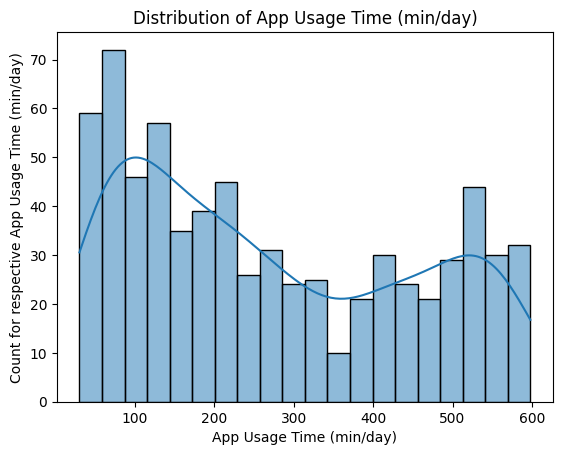

In [ ]:
sns.histplot(data1_mobile_usage, x='App Usage Time (min/day)', kde=True, bins=20)
plt.title('Distribution of App Usage Time (min/day)')
plt.ylabel('Count for respective App Usage Time (min/day)')
plt.xlabel('App Usage Time (min/day)')
plt.show()

### **Insight 2**

- **Insight statement**: The dataset has significantly much more Android user than iOS user
- **Supporting evidence**: The countplot depicts the distribution of users by operating systems.From the countplot it can be seen that Android has more than 500 users whereas iOS has around 150 users, which clearly indicates that the number of Android user is approximately 4 times more than the iOS users.
- **Analysis Type**: An Univariate analysis was conducted with countplot for the visualization of the frequency distribution of a single categorical variable "Operating systems" of the dataset .

The code for reproducing the histogram is provided below.

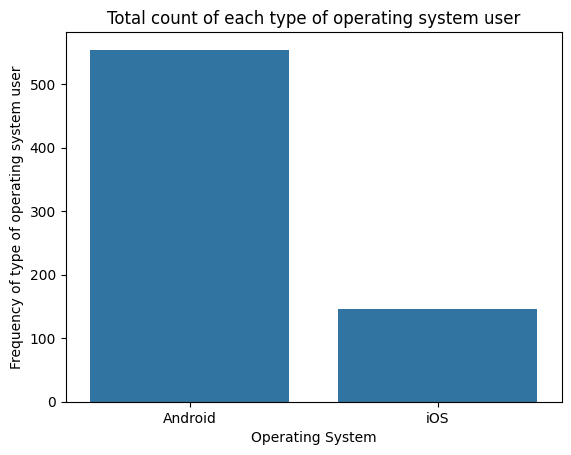

In [ ]:
sns.countplot(data=data1_mobile_usage, x='Operating System')
plt.title('Total count of each type of operating system user')
plt.ylabel('Frequency of type of operating system user')
plt.xlabel('Operating System')
plt.show()

### **Insight 3**

- **Insight statement**: Middle aged users are the predominant users of android operating system, whereas iOS is almost similarly distributed among adult, middle aged, and elderly age group.
- **Supporting evidence**: From the countplot, it is clear that Android devices are very popular among middle aged people. The count for middle aged Android users are more than 250, which is significantly larger than that of iOS users. We can also claim from the graph that, the number of iOS users among adult and elderly age groups are almost identical.
- **Analysis Type**: (r3) Grouped data countplot was used for this analysis. The objective was to find out the distribution of two of the operating systems among different age groups. To accomplish the objective, the "Age" column of the dataset was grouped into four (youth, adult, middle age, elderly) groups and then get the distribution of preferred operating systems among the groups.


- The code for reproducing the countplot is provided below.

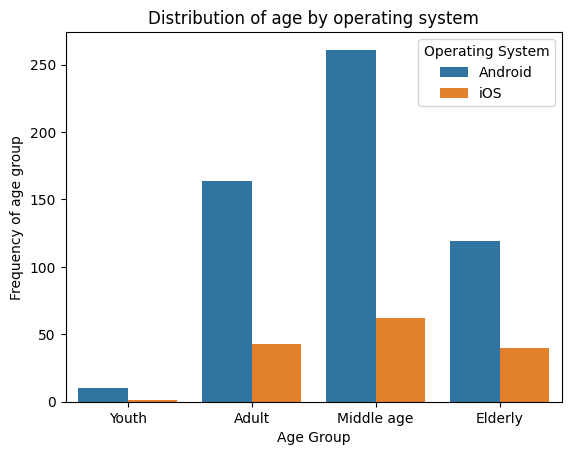

In [ ]:
#copy the dataset so that the actual dataset do not gets altered
temp_data = data1_mobile_usage.copy()
# Define Age_Group as a string to be used as new col name
Age_Group = 'Age_Group'
# Create  labels for groups
labels = ["Youth", "Adult", "Middle age", "Elderly"]
temp_data[Age_Group] = pd.cut(temp_data['Age'], bins = [0, 18, 30, 50, 100], labels = labels)

#draw the graph
sns.countplot(data = temp_data, x = Age_Group, hue = "Operating System")
plt.title('Distribution of age by operating system')
plt.ylabel('Frequency of age group')
plt.xlabel('Age Group')
plt.show()


### **Insight 4**

- **Insight statement**: There are gender preferences for different device models.  
- **Supporting evidence**: From the bars corresponding to the preferences for device models, it can be said that there exists significant disparity of  preferences for the device model "Sumsung Galaxy S21" between male and female. The countplot shows that almost 80 men from the dataset prefer Samsung, whereas the number of females are around 55. Additionally, the preference distriubution for "Google Pixel" and "iPhone12" are quite close for both male and female. Moreover, the graph also depicts that "Xiaomi Mi 11" are most popular among females and least popular among males.
- **Analysis Type**: (r4) Bivariate analysis between two categorical variables was conducted for this insight. This analysis examines the reltionship between two categorical variables of the dataset.


- The code for reproducing thevisual component is provided below.

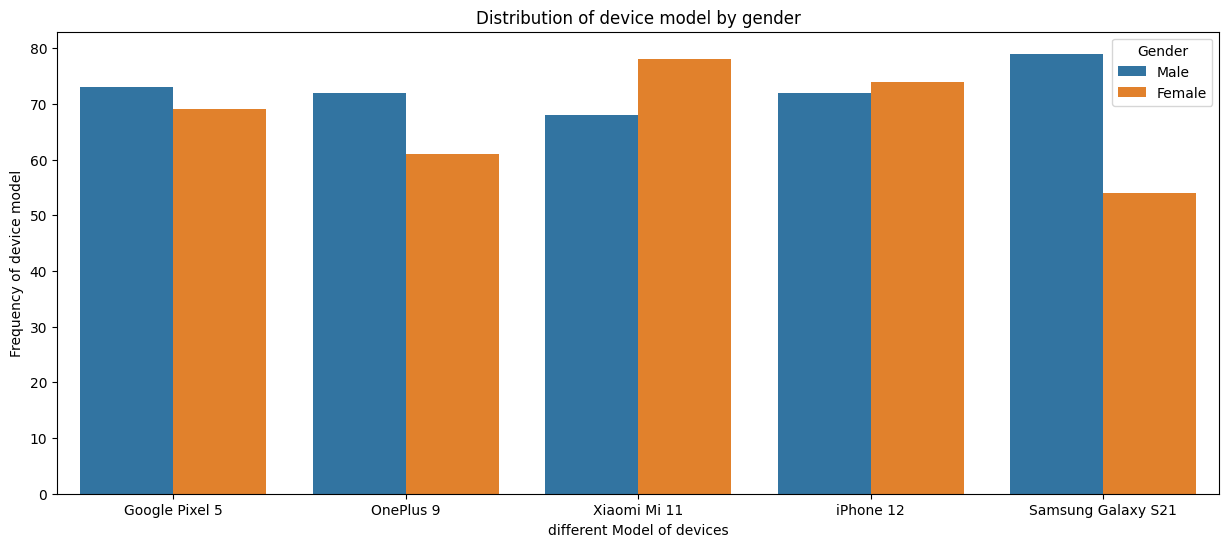

In [ ]:
plt.figure(figsize=(15, 6))
sns.countplot(data = data1_mobile_usage, x = 'Device Model', hue = "Gender")
plt.title('Distribution of device model by gender')
plt.xlabel('different Model of devices')
plt.ylabel('Frequency of device model')
plt.show()


### **Insight 5**

- **Insight statement**: The popularity of device models varies significantly among the user behavior classes.
- **Supporting evidence**: The graph depicts the prefernces of device models among different user behavior classes. The X-axis of the graph has the device model names sorted in an ascending order by thier usage frequency and Y axis has the counts of devices for each user behavior class respectively.
From the graph, we can see that, the device model "Xiaomi MI 11" has the highest frequency and "Samsung Galaxy S21" has the lowest frequency. Also, we can map from the graph that, "Xiaomi MI 11" is most popular to user behavior class 3; "iPhone 12" is most popular to user behavior class 2, and 3; "Google Pixel5" is most popular to user behavior class 3; "OnePlus9" is most popular to user behavior class 2; and "Samsung Galaxy S21" is most popular to user behavior class 4.
- **Analysis Type**: (r5) Bivariate analysis for two categorical variables ("Device Model" orderd in asc and "User Behavior Class") was conducted here. This
 type of analysis is used to find the usage patterns of various device models accross diffrent classes. The countplot visually represents the trends and comparison of preferences of device models among all the user behavior classes.

- The code for reproducing the visual component is provided below.

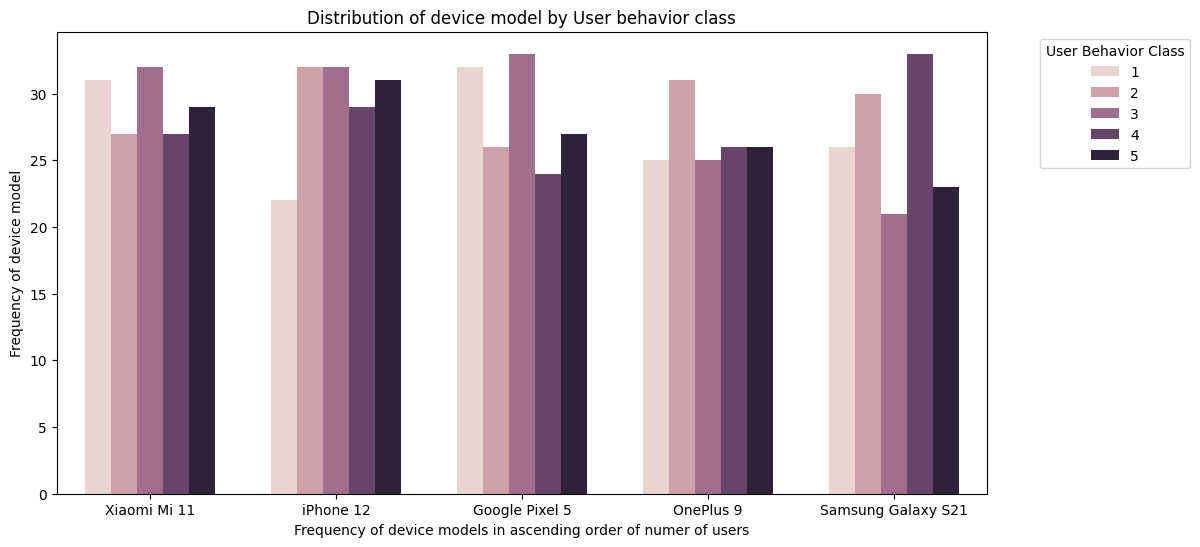

In [ ]:
#order by frequency--> This counts each device model and
#arranges the device model from most frequently used to least frequently used on the x-axis by default ascending is true.
ordred_device_model = data1_mobile_usage['Device Model'].value_counts().index
plt.figure(figsize=(12,6))
sns.countplot(data = temp_data, x = 'Device Model', hue = 'User Behavior Class', order = ordred_device_model,dodge = True, width=0.7)
plt.title('Distribution of device model by User behavior class')
plt.xlabel('Frequency of device models in ascending order of numer of users')
plt.ylabel('Frequency of device model')
# Adjust the legend to make the plot less cluttered
plt.legend(title='User Behavior Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


### **Insight 6**

- **Insight statement**: There is a positive correlation between the two variables "Battery Drain (mAh/day)" and "App Usage Time (min/day)".
- **Supporting evidence**: From the scatterplot we can see multiple clusters formed in a positive correlation manner.Thus it can be claimed that as app usage time increase, the battery drainage increase as well. The opposite relation is where with the increasing battery drainage, it can be said that the app usage has increased.
- **Analysis Type**: (r6) Bivariate analysis for two numerical variables( app usage, and battery drainage) was conducted to verify if there is any correlation between these two variables.

- The code for reproducing the visual component is provided below.

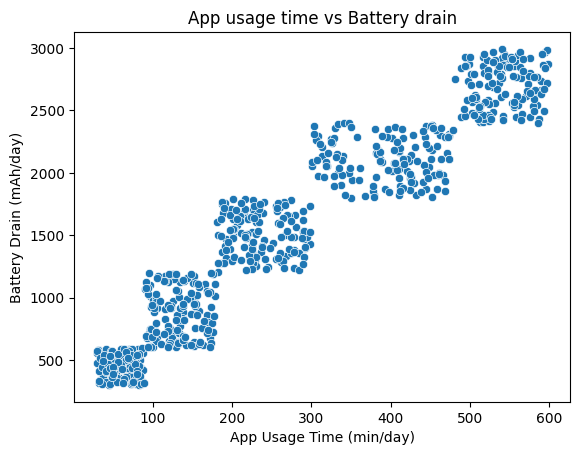

In [ ]:
sns.scatterplot(data = data1_mobile_usage,  x = 'App Usage Time (min/day)', y = 'Battery Drain (mAh/day)')
plt.title('App usage time vs Battery drain')
plt.xlabel('App Usage Time (min/day)')
plt.ylabel('Battery Drain (mAh/day)')
plt.show()

### **Insight 7**

- **Insight statement**: There is a positive correlation between the two variables "Battery Drain (mAh/day)" and "Screen On Time (hours/day)".
- **Supporting evidence**: From the scatterplot we can see multiple clusters formed in a positively correlated manner.Thus it can be claimed that as screen on time increase, the battery drainage increase as well. The opposite relation is where with the increasing battery drainage, it can be said that the screen on time has increased.
- **Analysis Type**: (r6) Bivariate analysis for two numerical variables( Screen on time, and battery drainage) was conducted to verify if there is any correlation between these two variables.



- The code for reproducing the visual component is provided below.

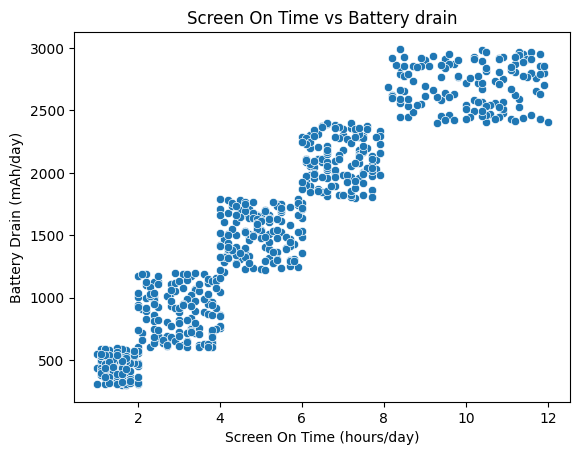

In [ ]:
sns.scatterplot(data = data1_mobile_usage,  x = 'Screen On Time (hours/day)', y = 'Battery Drain (mAh/day)')
plt.title('Screen On Time vs Battery drain')
plt.xlabel('Screen On Time (hours/day)')
plt.ylabel('Battery Drain (mAh/day)')
plt.show()

### **Insight 8**

- **Insight statement**: There is a positive correlation between the three variables "App usage time (min/day)", "Screen On Time (hours/day)", and "Number of Apps installed".
- **Supporting evidence**: From the scatterplot we can see multiple clusters formed in a positively correlated manner.Thus it can be claimed that as app usage time increase, the screen on time increase as well. The opposite relation is where with the increasing screen on time, it can be said that the app usage time has increased. The third variable "Number of apps installed" is color coded and we can see that the the color which indicates more apps are concentrated more heavily in areas where the other two variables are higher. Thus, it is apparent that users who spend more time on thier devices and keeps their screen on for longer periods, tends to have more apps installed in their devices.
- **Analysis Type**: (r6) Bivariate analysis for three numerical variables( Screen on time, app usege time, and number of apps installed) was conducted to verify if there is any correlation between these three variables. Two variables (app useage time, and screen
 on time) was used as x and y respectively. The other variable "Number of apps installed" was used as legend and color coded.
- The code for reproducing the visual component is provided below.

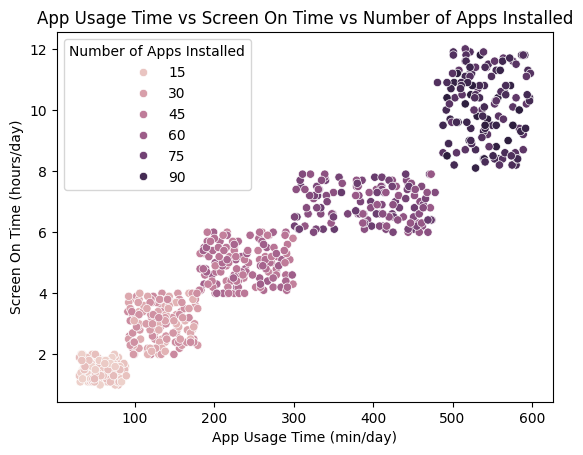

In [ ]:
sns.scatterplot(data = data1_mobile_usage,  x = 'App Usage Time (min/day)', y = 'Screen On Time (hours/day)', hue ='Number of Apps Installed')
plt.title('App Usage Time vs Screen On Time vs Number of Apps Installed')
plt.xlabel('App Usage Time (min/day)')
plt.ylabel('Screen On Time (hours/day)')
plt.show()

### **Insight 9**

- **Insight statement**: Male user shows tendency of consuming more/equal data than their female counterpart accross different user behavior classes.
- **Supporting evidence**: From the boxplot, we can see that the median values for males are higher than females for user behavior classes- 1, 2, 3, and 4. For user behavior class 5, the medians are almost equal for both male and female.The interquartile range (IQR) for males are broader than females indicating more variability of data usage among males than females. Also, we can see that different user behavior classes have differnt median and ranges depicting varying usage patterns among the classes. There are no outliers in the dataset since we can see no data points lies beyond the maximum quartile or the end of whiskers
- **Analysis Type**: (r7) Bivariate analysis between categorical and numerical analysis was conducted. The

 analysis accompanies boxplots to visually compare the central tendency and the dispersion of data usage from the median point between males and females across every user behavior class.

- The code for reproducing the visual component is provided below.

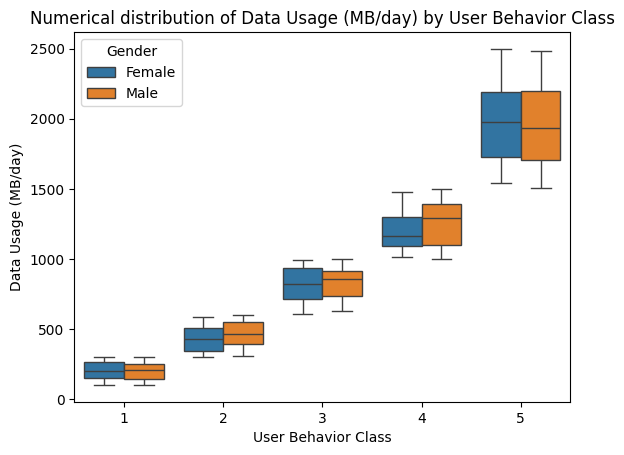

In [ ]:
sns.boxplot(data = data1_mobile_usage, x = 'User Behavior Class', y = 'Data Usage (MB/day)', hue='Gender')
plt.title('Numerical distribution of Data Usage (MB/day) by User Behavior Class')
plt.xlabel('User Behavior Class')
plt.ylabel('Data Usage (MB/day)')
plt.show()


### **Insight 10**

- **Insight statement**: The app usage time varies accross differnt user behavior classes along with the numerical distribution of the datapoints. The usage pattern and distribution also has a slight variation between males and females.
- **Supporting evidence**: From the violin plots we can get the summary statistics (median, range) as well as visualize the distribution probability of datapoints. From the violin plot, we can see that class 4 has more broader range compare to other classes. We can also visualize the density probability  of datapoints for all the behavior classes.
For example, from the graph, we can see that the probability distribution of datapoints is more prevalent around the median for classes 2, 4, and 5. However, for class 1, the disribution of datapoints is slightly high in the first quartile and for class 3 whereas the probability distribution of datapoints for class 1 is higher in last quartile.
- **Analysis Type**: (r7) Bivariate analysis between categorical and numerical analysis was conducted. The analysis accompanies violin plot to visually compare the central tendency and the distribution of data points for the variable "App Usage Time (min/day)" by the user behavior classes. The violin plot has been color coded to compare the distribution differences between males and females.

- The code for reproducing the visual component is provided below.

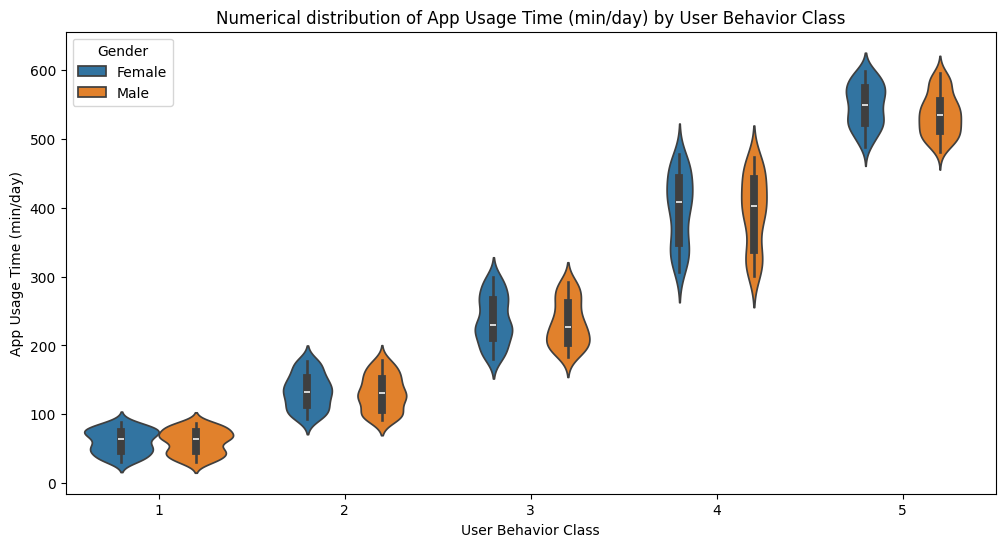

In [ ]:
plt.figure(figsize=(12, 6))
sns.violinplot(data = data1_mobile_usage, x = 'User Behavior Class', y = 'App Usage Time (min/day)', hue='Gender')
plt.title('Numerical distribution of App Usage Time (min/day) by User Behavior Class')
plt.xlabel('User Behavior Class')
plt.ylabel('App Usage Time (min/day)')
plt.show()

**Initial investigation on the dataset 1 to start with EDA analysis**

In [ ]:
#sns.pairplot(data1_mobile_usage)
# histplot for numerical data
# numeric_features = ['User ID', 'App Usage Time (min/day)', 'Screen On Time (hours/day)', 'Battery Drain (mAh/day)', 'Number of Apps Installed', 'Data Usage (MB/day)','Age','User Behavior Class']
# for i, feature in enumerate(numeric_features, 1):
#     plt.figure()
#     sns.histplot(data1_mobile_usage, x=feature, bins = 20)
#     plt.title('Frequency of '+ feature)

#Bar plot for categorical data
# categorical_features = ['Device Model', 'Operating System','Gender']
# for i, feature in enumerate(categorical_features, 1):
#     plt.figure()
#     sns.countplot(data=data1_mobile_usage, x=feature)
#     plt.title('Frequency of '+ feature)


In [ ]:
### Correlation check
# heatmap for correlation
# numeric_features= data1_mobile_usage.select_dtypes(include=['number']).columns
# plt.figure(figsize=(10, 8))
# sns.heatmap(data1_mobile_usage[numeric_features].corr(), annot=True, cmap='coolwarm')
# plt.title('Correlation Heatmap')
# plt.show()



--------------------------------------------------------------------------------



## **Description of dataset 2 (Placement Prediction Dataset)**
 This dataset is about the academic achievements, trainings, and extracarricular activities of a group of students.This dataset has 10,000 rows and 12 coloums. Each row represents a student and each column represents various features representing academic achievements of that particular student. The data set has diffrent types of feature such as CGPA, Internships, Projects, Workshops/Certifications etc.

 Some of the key features along with a brief description is provided below:

- **CGPA**: The overall grade points achieved by students, which is a numerical data of type float64.
- **Internships**:The number of internship a student has done , which is a numerical data of type int64.
- **Projects**:The number of projects a student has completed, which is a numerical data of type int64.
- **Workshops/Certifications**: The number of online courses taken by the students to upskill themselves, which is a numerical data of type int64.
- **AptitudeTestScore**:The grade achieved by students in their recruitment process test to test the Quant and logical thinking of students, which is a numerical data of type int64.
- **SoftSkillsRating**: The quantative representation of a student's communication skill,  which is a numerical data of type float64.
- **SSC_Marks**:The grade achieved by a student in the senior secondary exam, which is a numerical data of type int64.
- **HSC_Marks**: The grade achieved by a student in the higher secondary exam, which is a numerical data of type int64.
- **ExtracurricularActivities** This variable represents the insight and personality of a student in respect to how much he/she is active other than the acdemic, which is a categorical data
- **PlacementTraining**:  This represents if a student has succesfully been able to manage a placemnt or not, which is a categorical data

## **Insights for dataset 2 (Placement Prediction Dataset)**

### **Insight 1**

- **Insight statement**: Most of the student's CGPA is clustered around the range of 7.5 and 8.5.
- **Supporting evidence**: From the histogram, we can see that the CGPA distribution has a wide range starting from 6.5 and ending at 9.0 . However, there is a significant peak particularly around the range of 7.5 and 8.5 indicating most of the students have acheived a CGPA point between this range. From the graph, it is also visible that, more than 1200 students has acheived a CGPA between 8.2 to 8.3.
- **Analysis Type**:(r1) Univariate analysis for the numerical variable "CGPA" was conducted here. The histogram perfectly shows the dispersion of CGPA among the students with a clear peak around 7.5 and 8.5.
- The code for reproducing the visual component is provided below.

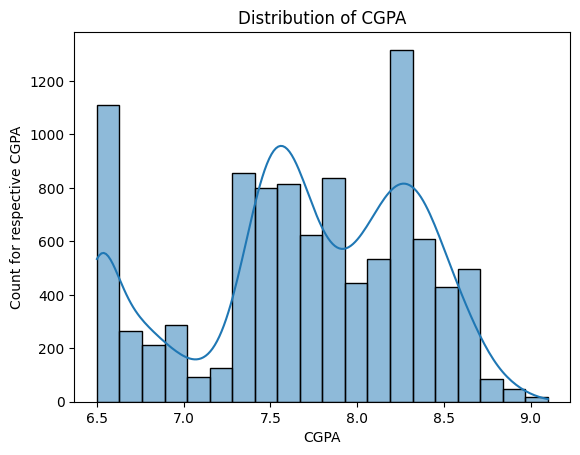

In [ ]:
sns.histplot(data2_placement_prediction, x='CGPA', kde=True, bins=20)
plt.title('Distribution of CGPA')
plt.ylabel('Count for respective CGPA')
plt.xlabel('CGPA')
plt.show()

### **Insight 2**


- **Insight statement**: Most of the students have not been able find a placement.
- **Supporting evidence**: From the countplot, we can see that a little more that 4000 students have been placed for a placement, whereas a little less than 6000 students have not been placed in any placement. The countplot clearly depicts the significant difference between the frequency of placed and notplaced student.
- **Analysis Type**:(r2) Univariate analysis for categorial variable "PlacementStatus" was conducted here. The countplot clearly depicts the significant diffrenece between the number of placed and notplaced students

- The code for reproducing the visual component is provided below.

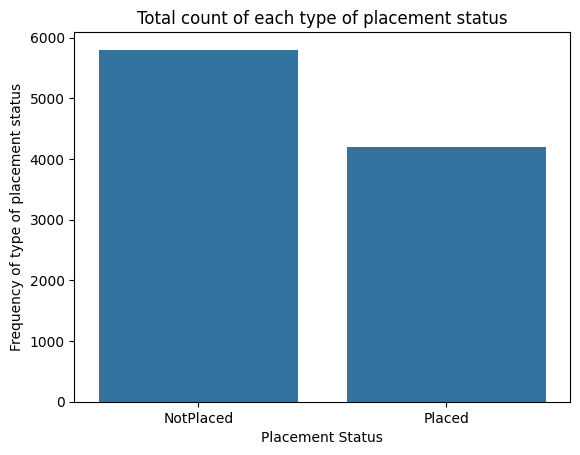

In [ ]:
sns.countplot(data=data2_placement_prediction, x='PlacementStatus')
plt.title('Total count of each type of placement status')
plt.xlabel('Placement Status')
plt.ylabel('Frequency of type of placement status')
plt.show()

### **Insight 3**

- **Insight statement**: There seems to have a positive correlation between the AptitudeTestScore and PlacementStatus.
- **Supporting evidence**: The countplot depicts an increasing trend between the aptitude test score and the PlacementStatus. The objective is to visualize the distribution of aptitute test score by placement status and find out if there is any correlation between the two. In order to achieve the objective, the column "AptitudeTestScore" was further categorized into 7 differnt letter grades ("C", "C+", "B", "B+", "A-", "A", and "A+"). The countplot clearly shows that students with higher aptitude test score constitues a larger proportion of placed students compared to those who scored relatively lower.
- **Analysis Type**:(r3) Grouped data countplot was used for this analysis. First the "AptitudeTestScore" column was categorized into different letter grades and then the distribution of letter grade over PlacementStatus was visually presented using the countplot.

- The code for reproducing the visual component is provided below.

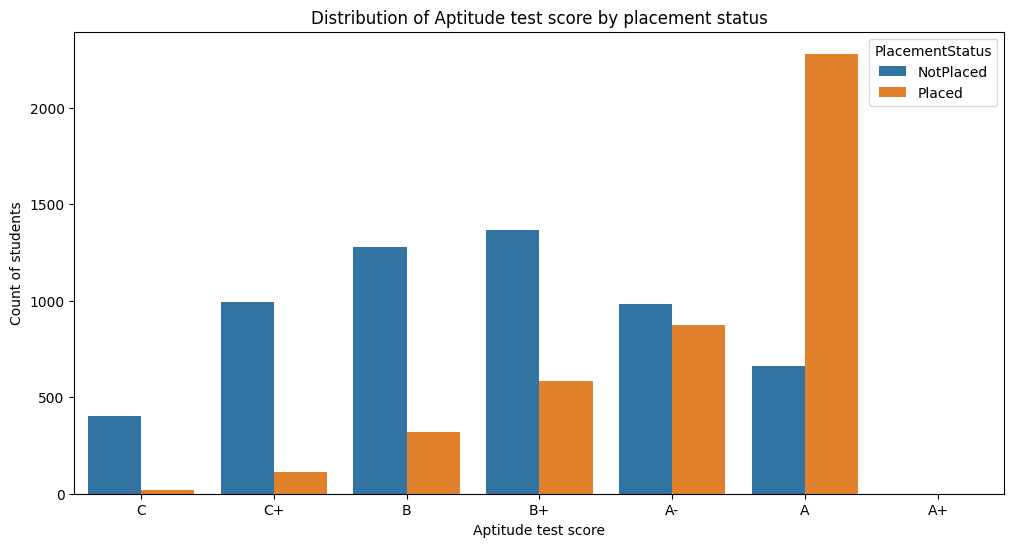

In [ ]:
#copy the dataset so that the actual dataset do not gets altered
temp_data_2 = data2_placement_prediction.copy()

# Define Aptitude_test_letter_grade_group as a string to be used as new col name
Aptitude_test_letter_grade_group = 'Aptitude_test_letter_grade_group'

# Create labels for groups
labels = ["C", "C+", "B", "B+", "A-", "A", "A+"]

# Apply pd.cut to the 'AptitudeTestScore' column and store the result in the new column
temp_data_2[Aptitude_test_letter_grade_group] = pd.cut(temp_data_2['AptitudeTestScore'], bins=[60, 65, 70, 75, 80, 85, 90, 100], labels=labels)

temp_data_2.head()

#create grouped data countplot
plt.figure(figsize=(12, 6))
sns.countplot(data = temp_data_2, x= 'Aptitude_test_letter_grade_group',  hue = 'PlacementStatus' )
plt.title('Distribution of Aptitude test score by placement status')
plt.ylabel('Count of students')
plt.xlabel('Aptitude test score')
plt.show()


### **Insight 4**

- **Insight statement**: Students who have received placement trainings are more likely to get a placement.
- **Supporting evidence**: From the countplot we can see that, the count of students who were placed successfully and have received Placement trainings are significantly larger than those who did not.The countplot clearly depicts the interrelation berween receiving training and successfully placed in a placement.
- **Analysis Type**: (r4) Bivariate analysis for two categorical variables "PlacementTraining" and "PlacementStatus" was condected here.

- The code for reproducing the visual component is provided below.

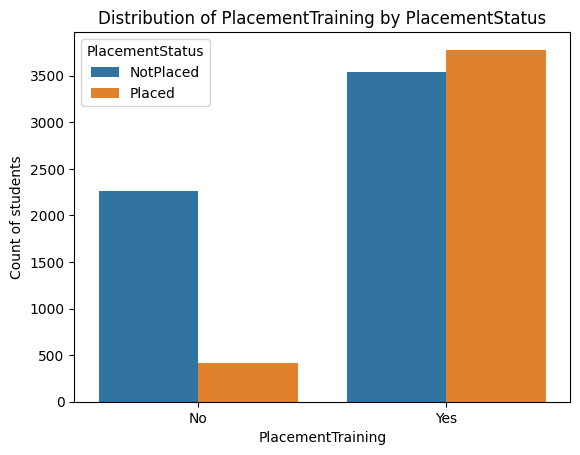

In [ ]:
sns.countplot(data = temp_data_2, x= 'PlacementTraining',  hue = 'PlacementStatus' )
plt.title('Distribution of PlacementTraining by PlacementStatus')
plt.ylabel('Count of students')
plt.xlabel('PlacementTraining')
plt.show()

### **Insight 5**

- **Insight statement**: The students who participated in extracaricular activities are more likely to achieve higher scores in the aptitude test.
- **Supporting evidence**: From the graph, it is clearly visible that students with good grades are more likely to participate in extracarricular activities. For example, the group of students who got an "A" in their test; only a few of them (around 400 students) have not participated in extracarricular activities. On the other hand, the group of students who got a "C"; majority of them have not participated in extracarricular activities. The objective of this graph was to look for possible pattern between the aptitude test scores and extracarricular activities. The grades were organized alphabetically to facilitate an easier understanding and comparison.
- **Analysis Type**:(r5) Bivariate analysis for  the two categorical variables(Aptitude_test_letter_grade_group, ExtracarricularActivities) was conducted here. The visual component have successfully depicts the emerging pattern between test grade and extracarricular activities.

- The code for reproducing the visual component is provided below.

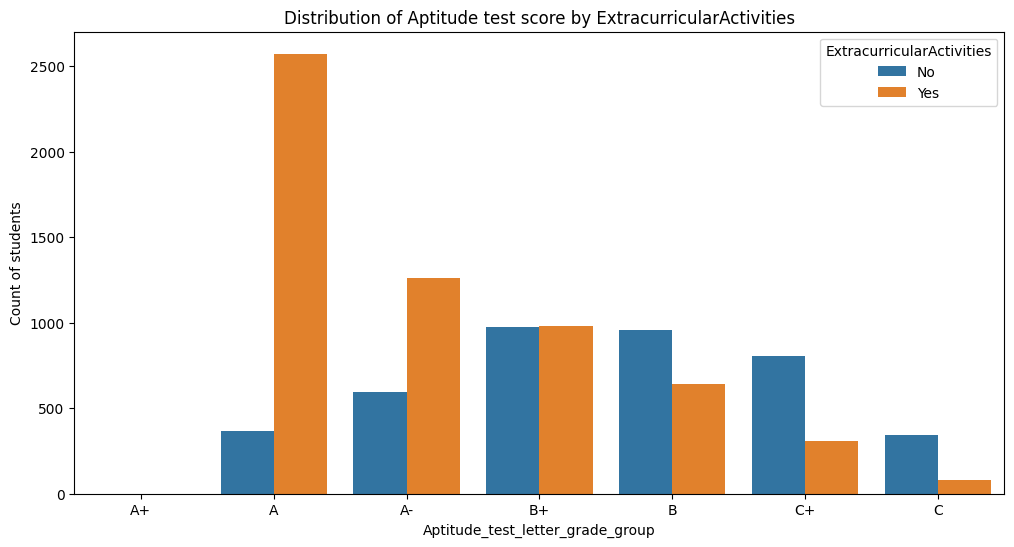

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data = temp_data_2, x= 'Aptitude_test_letter_grade_group', hue='ExtracurricularActivities', order = ['A+', 'A', 'A-', 'B+', 'B','C+', 'C'] )
plt.title('Distribution of Aptitude test score by ExtracurricularActivities')
plt.xlabel('Aptitude_test_letter_grade_group')
plt.ylabel('Count of students')
plt.show()


### **Insight 6**

- **Insight statement**:There is no significant correlation between the numerical variables 'AptitudeTestScore' and 'HSC_Marks'.
- **Supporting evidence**:From the scatterplot,  we can see that the dots on the scatterplot are uniformly distributed across a wide range of Aptitude Test Scores and HSC Marks. There is no visible trend or pattern suggesting a relationship where higher aptitude scores correspond to higher or lower HSC Marks. In an indicative correlation, we expect to see a cluster of points forming a discernible line or curve, either upward (positive correlation) or downward (negative correlation). Here, the points do not show any such alignment. The scatter of data points remains consistent across the range of scores, meaning the variability in HSC Marks does not seem to depend on the Aptitude Test Scores.
- **Analysis Type**: (r6) Bivariate analysis examining the relationship between two numerical variables 'AptitudeTestScore' and 'HSC_Marks' was conducted here.

- The code for reproducing the visual component is provided below.

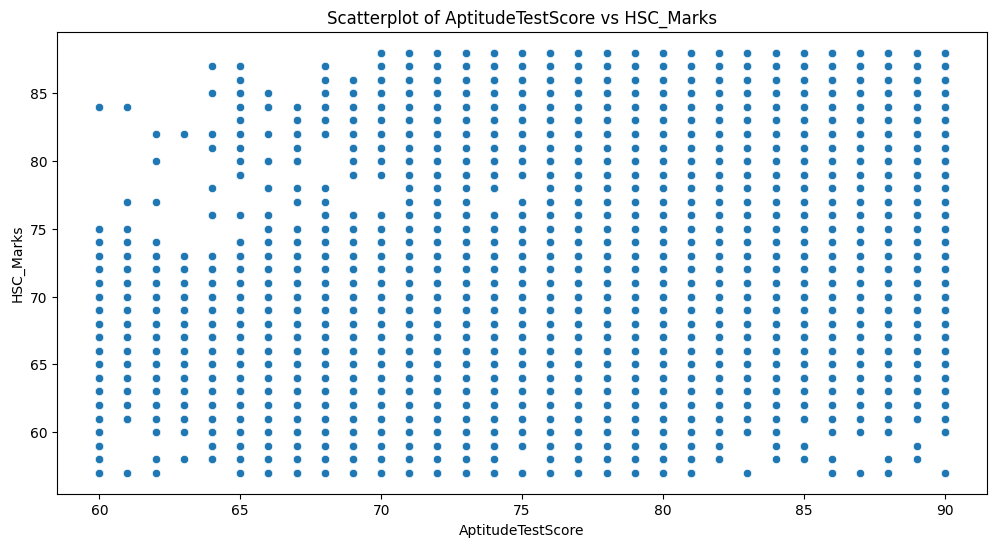

In [ ]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data = data2_placement_prediction, x = 'AptitudeTestScore', y = 'HSC_Marks')
plt.title('Scatterplot of AptitudeTestScore vs HSC_Marks')
plt.xlabel('AptitudeTestScore')
plt.ylabel('HSC_Marks')
plt.show()

***More insight for correlation for dataset 2***
- In order to find out any existing correlation between the numerical variables a heatmap has been created. From the heatmap, we can ensure that the dataset has no visible correlation between it's numerical variables.

The code to generate a heatmap is provided below:

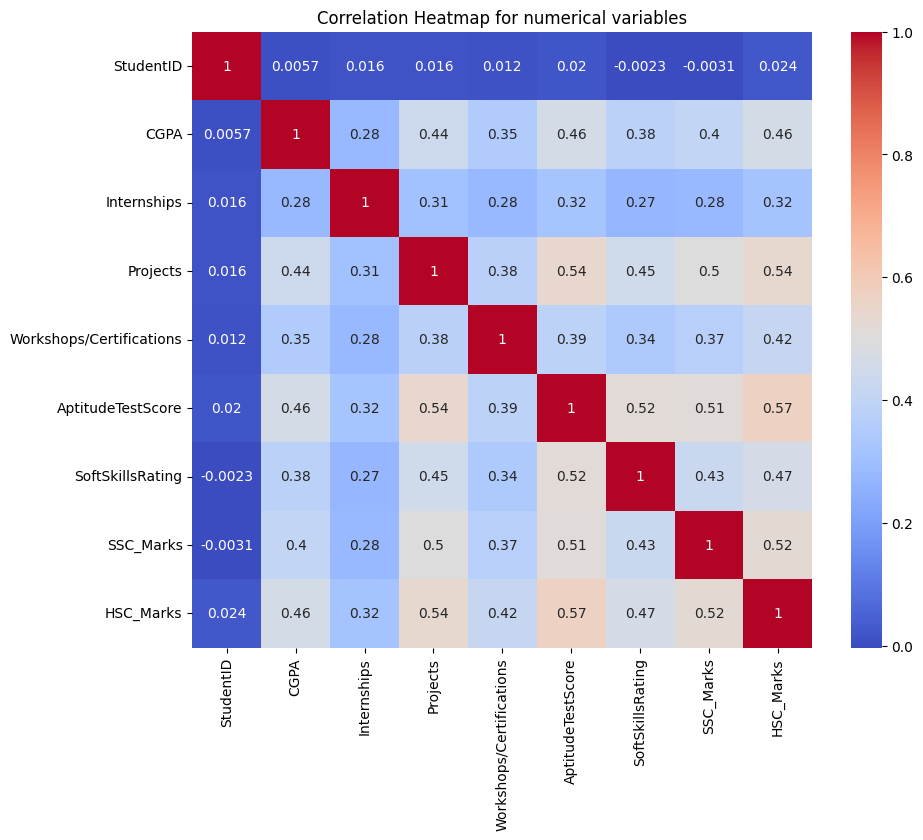

In [ ]:
# heatmap for correlation
# # #select the numeric variables
numeric_features_2 = data2_placement_prediction.select_dtypes(include=['number']).columns
plt.figure(figsize=(10, 8))
sns.heatmap(data2_placement_prediction[numeric_features_2].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap for numerical variables')
plt.show()


### **Insight 7**

- **Insight statement**: Students with higher aptitude test grades generally exhibits higher HSC marks as well.   
- **Supporting evidence**: From the boxplot, it is clear that as the median of HSC scores shows an upward trend as we go from "C" to "A". This indicates that median marks for HSC are higher for students in higher aptitude categories (A and B) compared to those in lower categories (C). Additionally, the distribution of HSC Marks as shown in the boxplot reveals that both the range and the spread of the interquartile region (IQR) increase as we move toward higher letter grades on the x-axis. This suggests greater variability among the top performers. The presence of data points outside the maximum range of the boxplot indicates outliers in the dataset, highlighting students whose performance is significantly different from the norm within their grade category.
- **Analysis Type**: (r7) Bivariate analysis between the categorical variable "Aptitude_test_letter_grade_group" and the numerical variable "HSC_Marks" has been conducted here. The analysis type is descriptive and comparative, aiming to visually represent and compare the central tendencies and distributions of numerical data across different categories of a categorical variable.


- The code for reproducing the visual component is provided below.

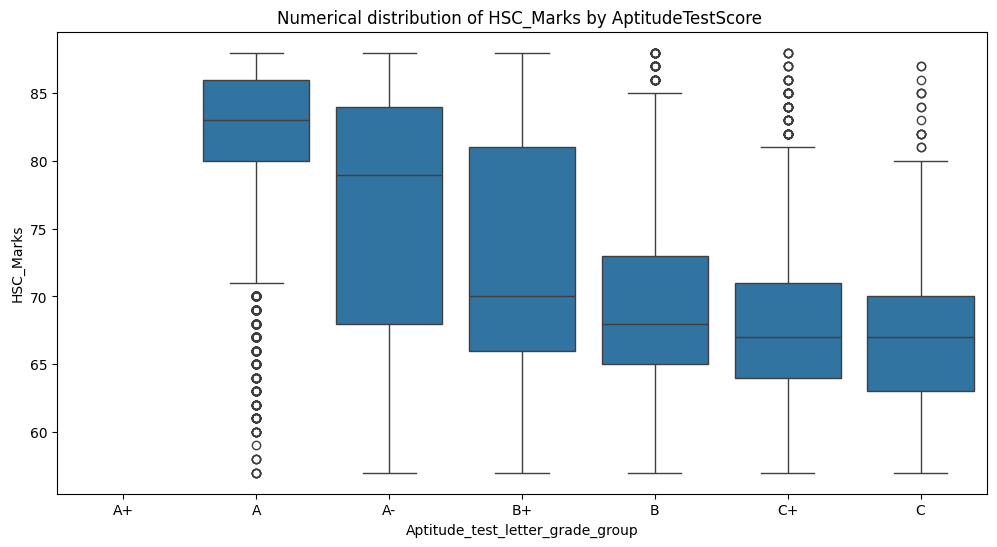

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data = temp_data_2, x = 'Aptitude_test_letter_grade_group', y = 'HSC_Marks', order = ['A+', 'A', 'A-', 'B+', 'B','C+', 'C'])
plt.title('Numerical distribution of HSC_Marks by AptitudeTestScore ')
plt.xlabel('Aptitude_test_letter_grade_group')
plt.ylabel('HSC_Marks')
plt.show()

### **Insight 8** ###


- **Insight statement**: Students with higher aptitude test grades generally exhibit higher SSC Marks, suggesting a correlation between aptitude test performance and secondary school achievements.
- **Supporting evidence**: From the boxplot, it is evident that the median of SSC Marks shows an upward trend as we progress from grade "C" to "A+". This trend indicates that median marks for SSC are higher for students in higher aptitude categories (A and B) compared to those in lower categories (C and C+). Additionally, the distribution of SSC Marks, as shown in the boxplot, reveals that both the range and the spread of the interquartile region (IQR) increase as we move toward higher letter grades on the x-axis. This increase in variability suggests greater diversity in scores among higher performers. The presence of data points outside the maximum range of the boxplot indicates outliers in the dataset, highlighting students whose performance significantly deviates from the norm within their grade category.
- **Analysis Type**: Bivariate analysis between the categorical variable "Aptitude_test_letter_grade_group" and the numerical variable "SSC_Marks" has been conducted here. The analysis type is descriptive and comparative, aiming to visually represent and compare the central tendencies and distributions of numerical data across different categories of a categorical variable.

- The code for reproducing thevisual component is provided below.

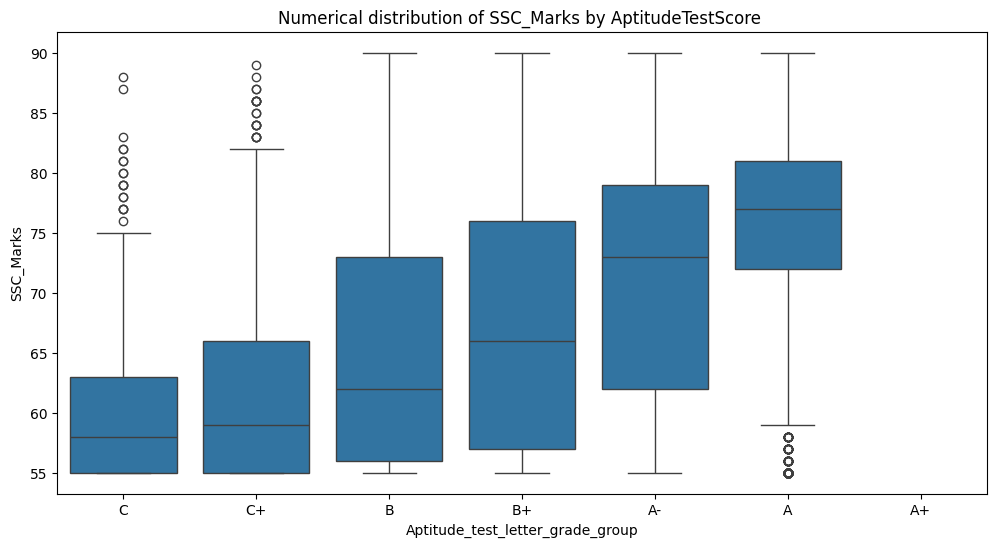

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data = temp_data_2, x = 'Aptitude_test_letter_grade_group', y = 'SSC_Marks')
plt.title('Numerical distribution of SSC_Marks by AptitudeTestScore ')
plt.xlabel('Aptitude_test_letter_grade_group')
plt.ylabel('SSC_Marks')
plt.show()

### **Insight 9** ###

- **Insight statement**: Students with placement training have a higher median soft skills rating along with a broader distribution; indicating that training positively correlates with better soft skill development.
- **Supporting evidence**: The violin plot provides a detailed comparison of Soft Skills Rating distributions for two groups of students— those who have received placement training ('Yes') and those who have not ('No'). The group who has received placement training have a higher median than those who did not receive any training. Additionally, we can also observe the distribution of SoftSkillsRating over the PlacemenTraining categories. For example, the spread of most of the datapoints for the training received group is around the median. However, we can also see a density spike around the maximum quartile of the inner boxplot indicating there are significant occurrences of higher ratings as well. On the other hand, the distribution for the group with no training is more concentrated around the median; indicating more concentrated set of lower ratings with less variability.
- **Analysis Type**: (r7) Bivariate analysis between a categorical variable "PlacementTraining" and a numerical variable "SoftSkillsRating" has been conducted here.This analysis employs a violin plot to visually represent and compare the central tendencies, dispersion, and overall distribution shape of soft skills ratings across the two distinct categories

- The code for reproducing the visual component is provided below.

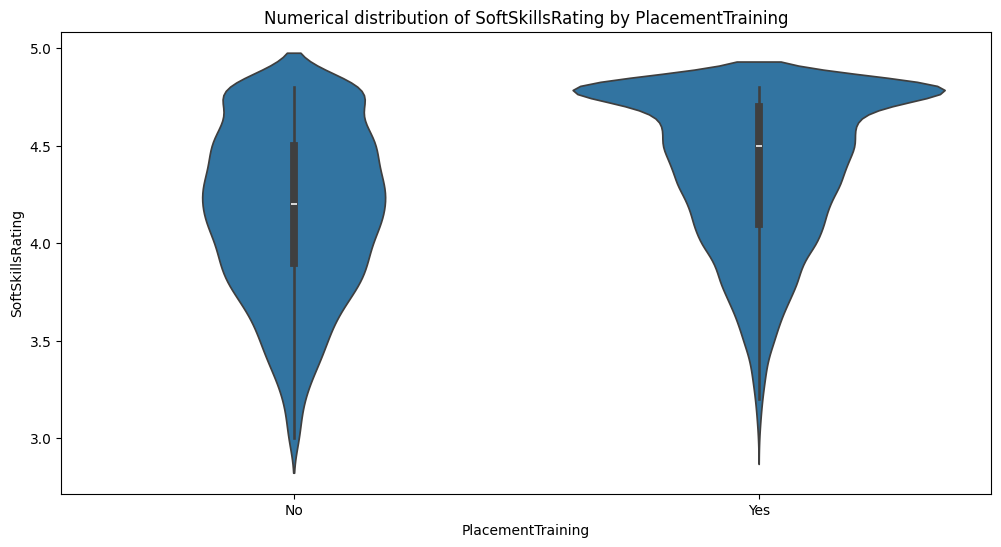

In [ ]:

plt.figure(figsize=(12,6))
sns.violinplot(data = temp_data_2, x = 'PlacementTraining', y = 'SoftSkillsRating')
plt.title('Numerical distribution of SoftSkillsRating by PlacementTraining')
plt.xlabel('PlacementTraining')
plt.ylabel('SoftSkillsRating')
plt.show()

### **Insight 10**

- **Insight statement**: Students who manage to obtain a placement, tend to have a higher CGPA compared to those with lower CGPA.
- **Supporting evidence**: The boxen plot displays multiple quantiles of the data for each category, providing a detailed view of the distribution. The median CGPA for 'Placed' students is higher than for 'NotPlaced' students highlighted by the IQR portion of the boxen plot. The width represents the density of datapoints within the quartile. The narrower quartile portion for 'Placed' category around the median depicts that this group has a denser concentration of higher CGPA. On the other hand, the interquartile segments for 'NotPlaced' categories are relatively wider indicating less dense distribution of datapoints. Outlier has been detected for both categories of students.
- **Analysis Type**: (r7) Bivariate analysis between a categorical variable "PlacementStatus" and a numerical variable "CGPA" has been conducted here. The graph is descriptive and comparative, focusing on visually depicting variations in CGPA across different placement outcomes to assess potential relationships between academic performance and placement success.


- The code for reproducing the visual component is provided below.


<Figure size 1200x600 with 0 Axes>

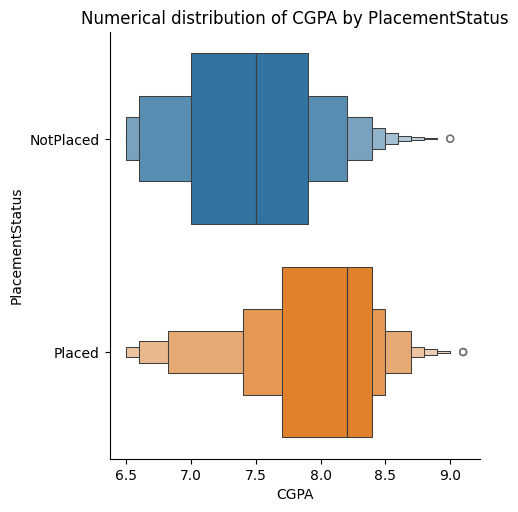

In [ ]:
plt.figure(figsize=(12,6))
sns.catplot(data = temp_data_2, y = 'PlacementStatus', x= 'CGPA', kind="boxen", hue = 'PlacementStatus')
plt.title('Numerical distribution of CGPA by PlacementStatus')
plt.xlabel('CGPA')
plt.ylabel('PlacementStatus')
plt.show()

**Initial investigation on the dataset 2 to start with EDA analysis**

In [ ]:
#sns.pairplot(data2_placement_prediction)

# # #h istplotar plot for numerical data
# numeric_features_2 = data2_placement_prediction.select_dtypes(include=['number']).columns
# print(numeric_features_2)
# for i, feature in enumerate(numeric_features_2, 1):
#     plt.figure()
#     sns.histplot(data2_placement_prediction, x=feature, bins = 20)
#     plt.title('Frequency of '+ feature)




# # #Bar plot for categorical data
# categorical_features_2 = data2_placement_prediction.select_dtypes(include=['object']).columns
# print(categorical_features_2)
# for i, feature in enumerate(categorical_features_2, 1):
#     plt.figure()
#     sns.countplot(data=data2_placement_prediction, x=feature)
#     plt.title('Frequency of '+ feature)

## **Conclusion**
The objective of this report is to successfully load a dataset from public server and then run Exploratory Data Analysis (EDA) on the dataset using variations of Univariate and Bivariate analysis methods. The EDA enables us to understand the underlinig trends, patterns, and correlation among various variables of the dataset. In this report we used differnt tactics to understand and visualize the patterns and interdepedency of variables. For visualization and creation of the visual components differnt Python libraries such as matplotlib. seaborn, Panda, and numpy etc were used.

## **References**
- https://seaborn.pydata.org/generated/seaborn.barplot.html#seaborn.barplot
- https://www.analyticsvidhya.com/blog/2022/07/step-by-step-exploratory-data-analysis-eda-using-python/
- https://www.analyticsvidhya.com/blog/2021/08/exploratory-data-analysis-and-visualization-techniques-in-data-science/
- https://www.analyticsvidhya.com/blog/2022/07/step-by-step-exploratory-data-analysis-eda-using-python/
- https://seaborn.pydata.org/tutorial/categorical.html#categorical-tutorial
- https://seaborn.pydata.org/generated/seaborn.move_legend.html
- https://mode.com/blog/violin-plot-examples
- https://seaborn.pydata.org/generated/seaborn.boxenplot.html#seaborn.boxenplot
- https://www.geeksforgeeks.org/box-plot-visualization-with-pandas-and-seaborn/




